In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

dataset_path = "/content/dataset/Indian-monuments/images"

print("Dataset exists:", os.path.exists(dataset_path))

Dataset exists: False


In [4]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".zip"):
            print(os.path.join(root, file))

/content/drive/MyDrive/indian_monuments.zip.zip


In [5]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/indian_monuments.zip.zip"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [6]:
import os

print(os.path.exists("/content/dataset/Indian-monuments/images/train"))
print(os.path.exists("/content/dataset/Indian-monuments/images/test"))

True
True


In [7]:
import tensorflow as tf

train_dir = "/content/dataset/Indian-monuments/images/train"
test_dir = "/content/dataset/Indian-monuments/images/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("Number of classes:", len(class_names))
print(class_names)

Found 3666 files belonging to 24 classes.
Found 1049 files belonging to 24 classes.
Number of classes: 24
['Ajanta Caves', 'Charar-E- Sharif', 'Chhota_Imambara', 'Ellora Caves', 'Fatehpur Sikri', 'Gateway of India', 'Humayun_s Tomb', 'India gate pics', 'Khajuraho', 'Sun Temple Konark', 'alai_darwaza', 'alai_minar', 'basilica_of_bom_jesus', 'charminar', 'golden temple', 'hawa mahal pics', 'iron_pillar', 'jamali_kamali_tomb', 'lotus_temple', 'mysore_palace', 'qutub_minar', 'tajmahal', 'tanjavur temple', 'victoria memorial']


In [8]:
import os

bad_file = "/content/dataset/Indian-monuments/images/train/iron_pillar/img622.jpg"

if os.path.exists(bad_file):
    os.remove(bad_file)
    print("Bad image removed.")
else:
    print("Bad image already removed.")

Bad image removed.


In [9]:
import tensorflow as tf

train_dir = "/content/dataset/Indian-monuments/images/train"
test_dir = "/content/dataset/Indian-monuments/images/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("Classes:", len(class_names))

Found 3665 files belonging to 24 classes.
Found 1049 files belonging to 24 classes.
Classes: 24


In [13]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Load pretrained EfficientNetB0
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model
base_model.trainable = False

# Build the model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(24, activation='softmax')
])

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │        30,744 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,080,315 (15.57 MB)

 Trainable params: 30,744 (120.09 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
model.save("/content/drive/MyDrive/landmark_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [16]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 90s 525ms/step - accuracy: 0.6398 - loss: 1.5823 - val_accuracy: 0.4709 - val_loss: 2.5109
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 26s 229ms/step - accuracy: 0.9105 - loss: 0.5568 - val_accuracy: 0.5081 - val_loss: 2.8283
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 45s 264ms/step - accuracy: 0.9441 - loss: 0.3498 - val_accuracy: 0.5205 - val_loss: 3.1132
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 26s 225ms/step - accuracy: 0.9588 - loss: 0.2603 - val_accuracy: 0.5195 - val_loss: 3.3294
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 30s 258ms/step - accuracy: 0.9694 - loss: 0.2086 - val_accuracy: 0.5243 - val_loss: 3.5188


In [11]:
from google.colab import files

uploaded = files.upload()

Saving indian_monuments.zip.zip to indian_monuments.zip.zip


In [17]:
import os
import random

test_dir = "/content/dataset/Indian-monuments/images/test"

all_images = []

for root, dirs, files in os.walk(test_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(root, file))

img_path = random.choice(all_images)

print(img_path)

/content/dataset/Indian-monuments/images/test/Gateway of India/166.jpg


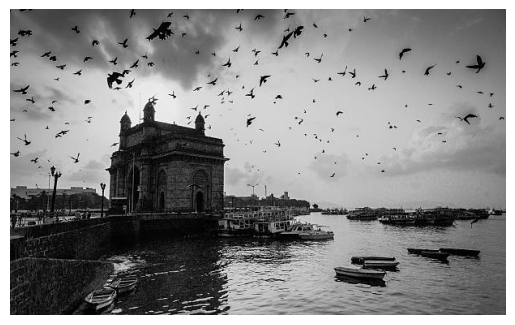

In [18]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [19]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

model = load_model(
    "/content/drive/MyDrive/landmark_model.h5",
    custom_objects={"preprocess_input": preprocess_input}
)

print("Model loaded successfully!")

Model loaded successfully!


In [20]:
import os

print(os.listdir("/content"))

['.config', 'dataset', 'indian_monuments.zip.zip', 'drive', 'sample_data']


In [24]:
import os
import random

folder = "/content/dataset/Indian-monuments/images/test/tajmahal"

img_path = random.choice([
    os.path.join(folder,f)
    for f in os.listdir(folder)
    if f.endswith(('.jpg','.jpeg','.png'))
])

print(img_path)

/content/dataset/Indian-monuments/images/test/tajmahal/99.jpg


In [25]:
import os
import random
from tensorflow.keras.preprocessing import image
import numpy as np

folder = "/content/dataset/Indian-monuments/images/test/tajmahal"

img_path = random.choice([
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if f.lower().endswith(('.jpg','.jpeg','.png'))
])

print(img_path)

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = float(np.max(prediction) * 100)

print("Predicted:", predicted_class)
print("Confidence:", confidence)

/content/dataset/Indian-monuments/images/test/tajmahal/gettyimages-470592191-612x612.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Predicted: Sun Temple Konark
Confidence: 9.595012664794922


In [26]:
from sklearn.metrics import accuracy_score

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print("Test Accuracy:", accuracy_score(y_true, y_pred))

Test Accuracy: 0.04861773117254528


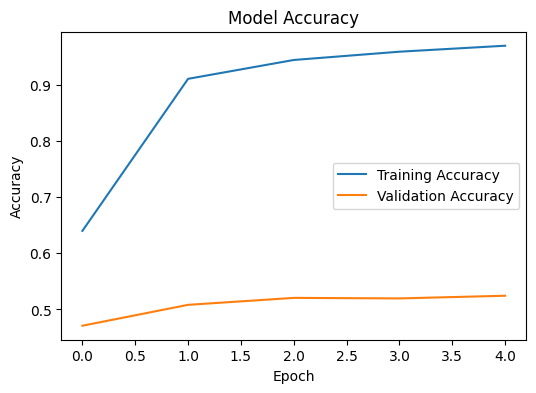

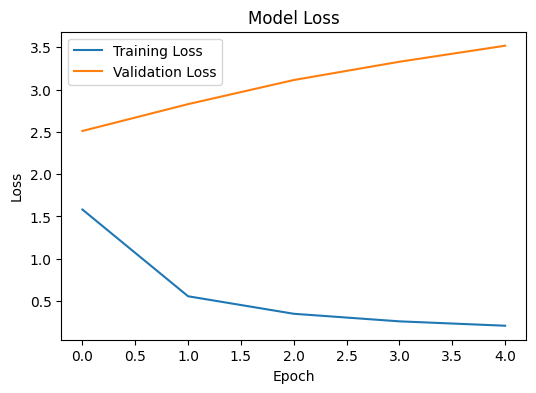

In [27]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("accuracy.png", dpi=300)
plt.show()

# Loss Graph
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig("loss.png", dpi=300)
plt.show()